In [ ]:
#Titulo: DIKW para Netflix
#Objetivo: Generación del conocimiento mediante el modelo DIKW
#Fecha: 21 de mayo

In [1]:
import pandas as pd

In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
#Carga el Dataset
df = pd.read_csv("netflix_titles.csv")

In [7]:
#Mostrar las primeras filas
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
#Mostrar las dimensiones
df.shape

(8807, 12)

In [10]:
#Mostrar los nombres de columnas
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [11]:
#Mostrar tipos de datos
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [12]:
#Limpieza de los datos
#Identificar valores nulos
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
#Calcular porcentaje de valores faltantes
df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [14]:
#Detectar registros duplicados
df.duplicated().sum()

np.int64(0)

In [15]:
#Aplicar estrategias de limpieza: eliminación y transformación
df_limpio = df.drop_duplicates()
df_limpio = df_limpio.dropna(subset=['title', 'type'])  #elimina filas críticas
df_limpio['country'] = df_limpio['country'].fillna('Unknown')
df_limpio['rating'] = df_limpio['rating'].fillna('Not Rated')
df_limpio['date_added'] = pd.to_datetime(df_limpio['date_added'], errors='coerce')

In [16]:
#Justificación
df_limpio.shape

(8807, 12)

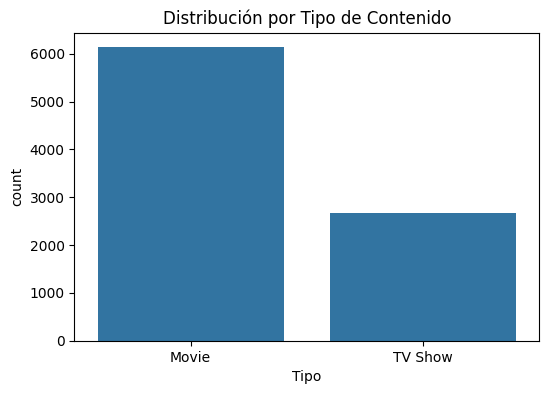

In [26]:
#Gráfica 1: Tipo de contenido
plt.figure(figsize=(6,4))
sns.countplot(df_limpio, x='type')
plt.title('Distribución por Tipo de Contenido')
plt.xlabel('Tipo')
plt.show()

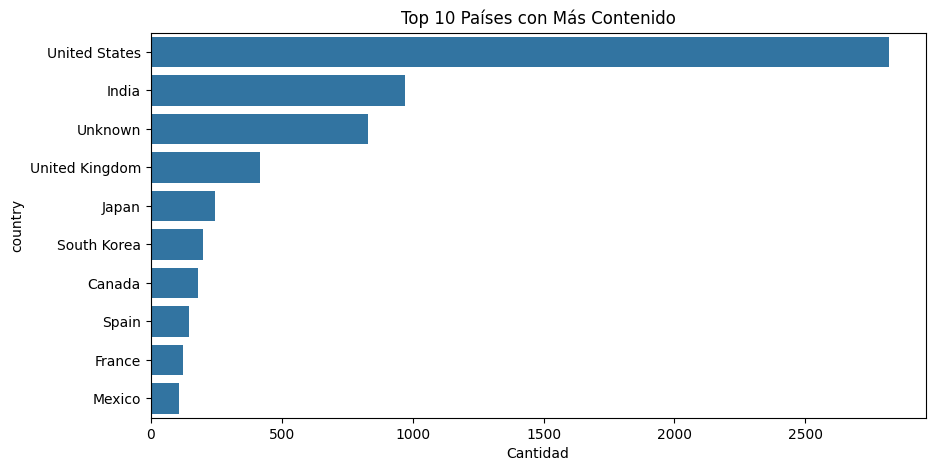

In [27]:
#Gráfica 2: Top 10 países
plt.figure(figsize=(10,5))
top_paises = df_limpio['country'].value_counts().head(10)
sns.barplot(x=top_paises.values, y=top_paises.index)
plt.title('Top 10 Países con Más Contenido')
plt.xlabel('Cantidad')
plt.show()

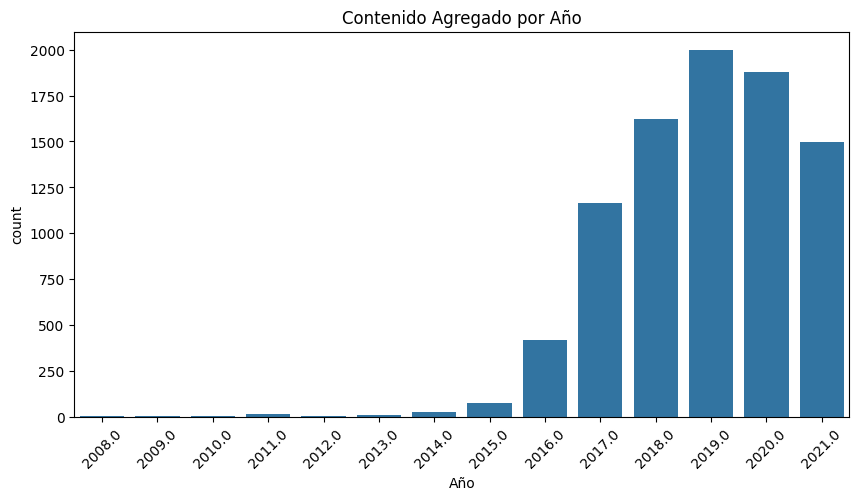

In [28]:
#Gráfica 3: Contenido por año
plt.figure(figsize=(10,5))
sns.countplot(df_limpio, x='year_added')
plt.title('Contenido Agregado por Año')
plt.xlabel('Año')
plt.xticks(rotation=45)
plt.show()

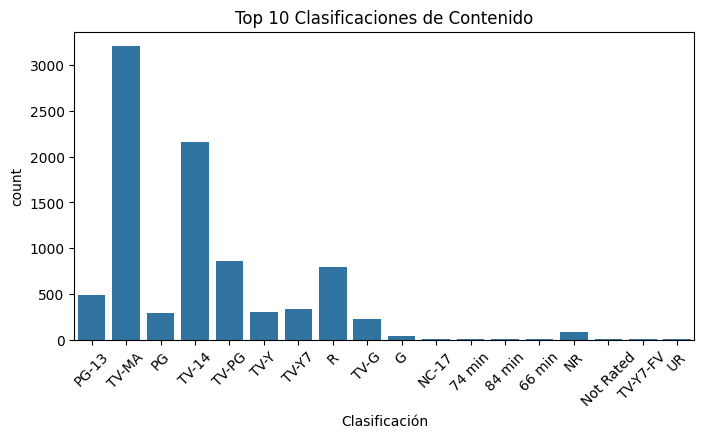

In [29]:
#Gráfica 4: Top 10 ratings
plt.figure(figsize=(8,4))
sns.countplot(df_limpio, x='rating')
plt.title('Top 10 Clasificaciones de Contenido')
plt.xlabel('Clasificación')
plt.xticks(rotation=45)
plt.show()

In [22]:
#Conclusión 1: La mayoría del contenido en Netflix son películas
df_limpio['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [23]:
#Conclusión 2: El país con más contenido es Estados Unidos
df_limpio['country'].value_counts().head(1)

country
United States    2818
Name: count, dtype: int64

In [24]:
#Conclusión 3: El año con más títulos agregados
df_limpio['year_added'].value_counts().head(1)

year_added
2019.0    1999
Name: count, dtype: int64